### Radial Equilibrium

To validate the axisymmetric solver we need to check the validity of the radial equilibrium equation for swirling flow

$$ 
\frac{dp}{dr} = \frac{\rho u_{\theta}^2}{r}
$$

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from unsflow.utils.plot_styles import *
import os 

In [83]:
intputFile = 'Volume_CSV/results.csv'
os.makedirs('Pictures', exist_ok=True)

# Read the first three lines to extract grid sizes
with open(intputFile, 'r') as f:
    ni = int(f.readline().strip().split('=')[1])
    nj = int(f.readline().strip().split('=')[1])
    nk = int(f.readline().strip().split('=')[1])

# Read the rest of the CSV data into a DataFrame
df = pd.read_csv(intputFile, skiprows=3)
data = {}

for field in df.columns:
    data[field] = np.reshape(df[field].values, (ni, nj, nk))



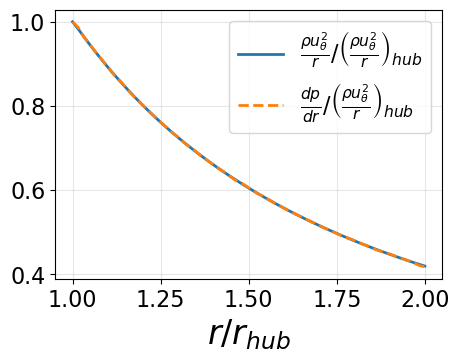

In [86]:
# extract the data at middle axial location
ncheck = ni-1
radius = data['y'][ncheck, :, 0]
utheta = data['Velocity Z'][ncheck, :, 0]
ux = data['Velocity X'][ncheck, :, 0]
density = data['Density'][ncheck, :, 0]
pressure = data['Pressure'][ncheck, :, 0]

dpdr = np.gradient(pressure, radius, edge_order=1)
rhs = density * (utheta**2 / radius)

norm = density[0]*utheta[0]**2/radius[0]

plt.figure(figsize=(5,3.5))
plt.plot(radius/radius.min(), rhs/norm, label=r'$\frac{\rho u_{\theta}^2}{r} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{hub}$', lw=2)
plt.plot(radius/radius.min(), dpdr/norm, '--', mfc='none', label=r'$\frac{dp}{dr} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{hub}$', lw=2)
plt.xlabel(r'$r/r_{hub}$')
# plt.ylabel(r'[Pa/m]')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Pictures/radial_equilibrium_check.pdf', bbox_inches='tight')

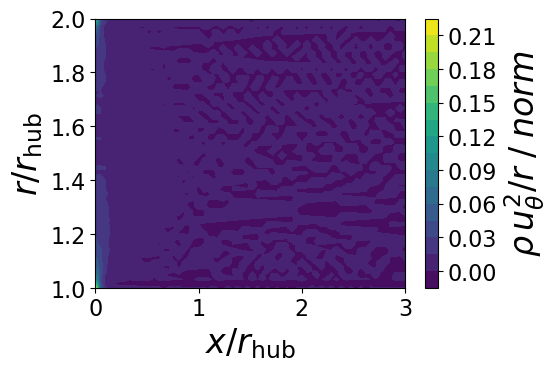

In [87]:
# 2d residual version
axis    = data['x'][:, :, 0]
r  = data['y'][0, :, 0]
radius = data['y'][:, :, 0]
utheta  = data['Velocity Z'][:, :, 0]
ux      = data['Velocity X'][:, :, 0]
density = data['Density'][:, :, 0]
pressure= data['Pressure'][:, :, 0]

dpdr = np.gradient(pressure, r, axis=1)
rhs  = density * (utheta**2 / radius)

norm = density[0, 0] * utheta[0, 0]**2 / radius[0]

fig, ax = plt.subplots(figsize=(5, 3.5))

cf = ax.contourf(
    axis   / radius.min(),   # x-axis: axial positions normalised by r_hub
    radius / radius.min(),   # y-axis: radial positions normalised by r_hub
    (rhs - dpdr)    / norm,
    levels=20,
    cmap='viridis'
)

fig.colorbar(cf, ax=ax, label=r'$\rho\, u_\theta^2 / r \;/\; norm$')

ax.set_xlabel(r'$x / r_\mathrm{hub}$')
ax.set_ylabel(r'$r / r_\mathrm{hub}$')

fig.savefig('Pictures/radial_equilibrium_check2D.pdf', bbox_inches='tight')